In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
from keras.applications import EfficientNetB0
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.models import Sequential
from keras.layers import Input, Dense, GlobalAveragePooling2D
from keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.efficientnet import preprocess_input
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import precision_score, recall_score, accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
import time
import os
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = "/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/train"
valid_path = "/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/valid"
test_path = "/content/drive/MyDrive/KLTN/Storage Dataset/Chest CT-Scan images Dataset/test"

In [ ]:
from collections import Counter
import os

def count_images_per_class(directory):
    class_counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            num_images = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])
            class_counts[class_name] = num_images
    return Counter(class_counts)


print("Train class distribution:", count_images_per_class(train_path))
print("Valid class distribution:", count_images_per_class(valid_path))
print("Test class distribution:", count_images_per_class(test_path))


Train class distribution: Counter({'adenocarcinoma': 195, 'squamous.cell.carcinoma': 155, 'normal': 148, 'large.cell.carcinoma': 115})
Valid class distribution: Counter({'adenocarcinoma': 23, 'large.cell.carcinoma': 21, 'squamous.cell.carcinoma': 15, 'normal': 13})
Test class distribution: Counter({'adenocarcinoma': 120, 'squamous.cell.carcinoma': 90, 'normal': 54, 'large.cell.carcinoma': 51})


In [ ]:
IMAGE_SHAPE = (224,224,3)
N_CLASSES = 4
BATCH_SIZE = 64

In [ ]:
train_datagen = ImageDataGenerator(
    dtype='float32',
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False
)
val_datagen = ImageDataGenerator(
    dtype='float32',

)
test_datagen = ImageDataGenerator(
    dtype='float32',
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
    shuffle = False,
)

validation_generator = val_datagen.flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
)

Found 613 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Found 72 images belonging to 4 classes.


In [ ]:
cls_train = train_generator.classes
cls_test = test_generator.classes
class_names = list(train_generator.class_indices.keys())
print(class_names)
num_classes = train_generator.num_classes
print("num classes:",num_classes)

['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
num classes: 4


In [ ]:
# Build the EfficientNetB0 model
res_model = EfficientNetB0(include_top=False, pooling='avg', weights='imagenet', input_shape = (IMAGE_SHAPE))

for layer in res_model.layers:
    if 'block7' not in layer.name:
        layer.trainable = False

model = Sequential()
model.add(res_model)
# model.add(layers.GlobalAveragePooling2D())
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(N_CLASSES, activation = 'softmax'))


# Compile the model
model.compile(optimizer='adam', loss = 'categorical_crossentropy', metrics = ['acc'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 724,916 (2.77 MB)

 Non-trainable params: 3,334,899 (12.72 MB)

In [ ]:
# Callback
checkpoint = ModelCheckpoint(filepath='/content/drive/MyDrive/KLTN/EfficientNetB0/Models/chest_CT_SCAN-EfficientNet.h5',
                            monitor='val_loss',
                            mode='auto',
                            save_best_only=True)
early_stopping = EarlyStopping(verbose=1, patience=3)

In [ ]:
# Đo thời gian huấn luyện
start_time = time.time()

history = model.fit(train_generator,
                    steps_per_epoch = 20,
                    epochs = 100,
                    verbose = 1,
                    validation_data = validation_generator,
                    callbacks = [checkpoint, early_stopping])

training_time = time.time() - start_time

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - acc: 0.4434 - loss: 1.5321

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


20/20 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - acc: 0.4868 - loss: 1.4117 - val_acc: 0.5556 - val_loss: 0.9942
Epoch 2/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - acc: 0.7167 - loss: 0.7068

20/20 ━━━━━━━━━━━━━━━━━━━━ 63s 659ms/step - acc: 0.7254 - loss: 0.6847 - val_acc: 0.6389 - val_loss: 0.8830
Epoch 3/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.8315 - loss: 0.4548

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 636ms/step - acc: 0.9516 - loss: 0.1540 - val_acc: 0.8611 - val_loss: 0.4986
Epoch 10/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - acc: 0.9621 - loss: 0.1316

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 652ms/step - acc: 0.9574 - loss: 0.1354 - val_acc: 0.8472 - val_loss: 0.4676
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 608ms/step - acc: 0.9498 - loss: 0.1216 - val_acc: 0.8333 - val_loss: 0.4725
Epoch 12/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - acc: 0.9655 - loss: 0.1203

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 652ms/step - acc: 0.9672 - loss: 0.1156 - val_acc: 0.8472 - val_loss: 0.4323
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 600ms/step - acc: 0.9679 - loss: 0.0929 - val_acc: 0.8472 - val_loss: 0.4713
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 594ms/step - acc: 0.9662 - loss: 0.0841 - val_acc: 0.8472 - val_loss: 0.4536
Epoch 15/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.9849 - loss: 0.0657

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 667ms/step - acc: 0.9786 - loss: 0.0771 - val_acc: 0.8750 - val_loss: 0.3570
Epoch 16/100
10/20 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - acc: 0.9771 - loss: 0.0841

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 672ms/step - acc: 0.9755 - loss: 0.0835 - val_acc: 0.8750 - val_loss: 0.3494
Epoch 17/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 605ms/step - acc: 0.9706 - loss: 0.0949 - val_acc: 0.8611 - val_loss: 0.4095
Epoch 18/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 593ms/step - acc: 0.9747 - loss: 0.0748 - val_acc: 0.8611 - val_loss: 0.3935
Epoch 19/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 562ms/step - acc: 0.9826 - loss: 0.0646 - val_acc: 0.8750 - val_loss: 0.4705
Epoch 19: early stopping


In [ ]:
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f'Test accuracy: {test_acc}')
print(f'Test Loss: {test_loss}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - acc: 0.9108 - loss: 0.2455
Test accuracy: 0.8761904835700989
Test Loss: 0.3158867359161377


In [ ]:
# Đánh giá chi tiết
y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step


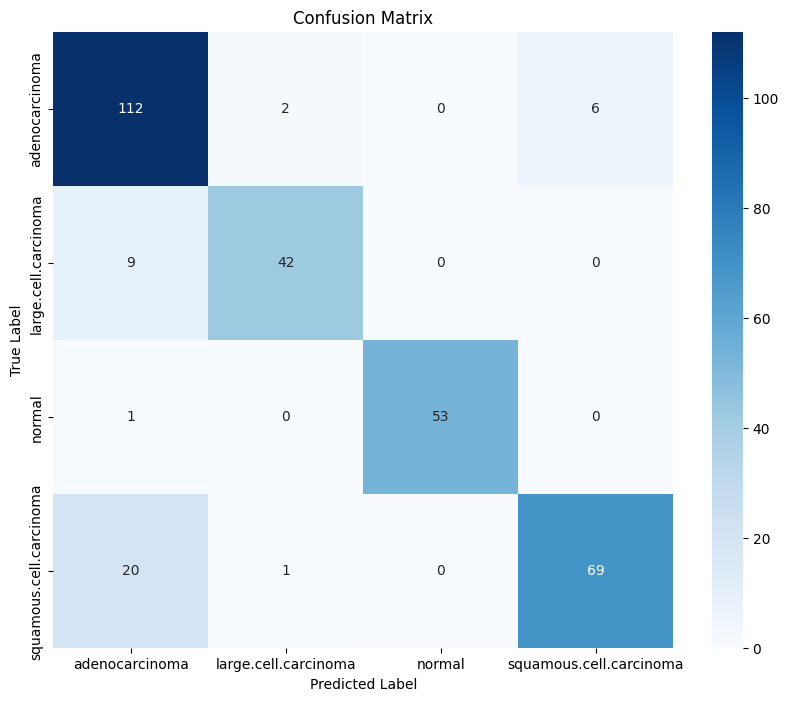

Classification Report:
                         precision    recall  f1-score   support

         adenocarcinoma       0.79      0.93      0.85       120
   large.cell.carcinoma       0.93      0.82      0.88        51
                 normal       1.00      0.98      0.99        54
squamous.cell.carcinoma       0.92      0.77      0.84        90

               accuracy                           0.88       315
              macro avg       0.91      0.88      0.89       315
           weighted avg       0.89      0.88      0.88       315



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

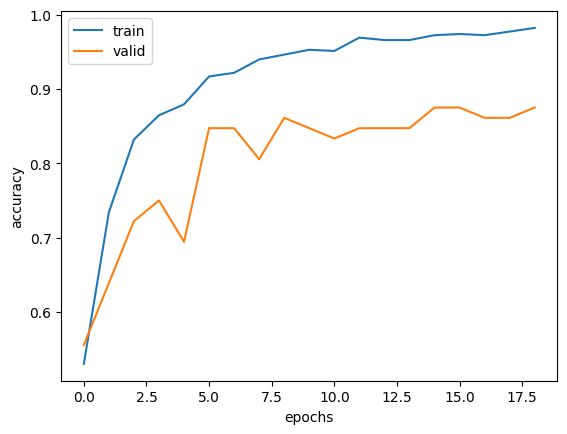

In [ ]:
# Vẽ biểu đồ accuracy
plt.plot(history.history['acc'], label='train')
plt.plot(history.history['val_acc'], label='valid')
plt.legend(loc='upper left')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.show()

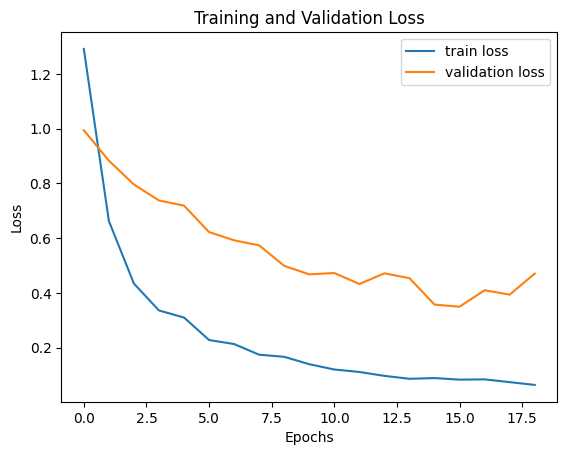

In [ ]:
# Vẽ biểu đồ loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Tính các chỉ số đánh giá
val_loss = history.history['val_loss'][-1]  # Categorical Crossentropy trên tập validation
# Số lượng epoch thực tế
epochs_trained = len(history.history['loss'])
# Số lượng mẫu trong tập train
num_samples = train_generator.samples
# Số đặc trưng (features) - kích thước ảnh (224, 224, 3)
num_features = np.prod(IMAGE_SHAPE)

In [ ]:
# In kết quả
print("Chỉ số:")
print(f"Loss Function (Categorical Crossentropy): {val_loss:.4f}")
print(f"Thời gian huấn luyện: {training_time:.2f} giây")
print(f"Số lượng epoch: {epochs_trained}")
print(f"Số lượng mẫu: {num_samples}")
print(f"Số đặc trưng: {num_features}")

Chỉ số:
Loss Function (Categorical Crossentropy): 0.4705
Thời gian huấn luyện: 463.34 giây
Số lượng epoch: 19
Số lượng mẫu: 613
Số đặc trưng: 150528
